## Павлусенко Ангеліна КН-42-15
Мета:Ознайомитися з принципами побудови асоціативних правил (association rule mining) на реальних даних користувацьких уподобань. Навчитись виконувати пошук частих наборів елементів (frequent itemsets) і формувати асоціативні правила за допомогою метрик support, confidence і lift на основі набору даних MovieLens Small. Розвинути навички попередньої обробки даних, перетворення даних у транзакційний формат і інтерпретації результатів.

На цьому етапі було завантажено дані та виконано їх об'єднання.Залишено лише оцінки користувачів ≥ 4.0, які вважаються позитивними.

In [24]:
#1 завдання
import pandas as pd

ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv('ml-latest-small/movies.csv')

ratings.head()
df = pd.merge(ratings, movies, on='movieId')
df.head()
df = df[df['rating'] >= 4.0]
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [25]:
print("Розмір таблиці:", df.shape)
print("Користувачів:", df['userId'].nunique())
print("Фільмів:", df['title'].nunique())

Розмір таблиці: (48580, 6)
Користувачів: 609
Фільмів: 6297


Сформовано транзакційну матрицю на основі користувацьких оцінокРядки матриці відповідають користувачам (userId), стовпці — фільмам (title).  

In [26]:
#2 завдання
basket = df.groupby(['userId', 'title'])['rating'] \
    .count().unstack().fillna(0)

basket = (basket > 0)
basket.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Salem's Lot (2004),'Til There Was You (1997),"'burbs, The (1989)",(500) Days of Summer (2009),*batteries not included (1987),...And Justice for All (1979),00 Schneider - Jagd auf Nihil Baxter (1994),1-900 (06) (1994),...,Zombieland (2009),Zookeeper (2011),Zoolander (2001),Zootopia (2016),Zulu (1964),[REC] (2007),[REC]² (2009),eXistenZ (1999),xXx (2002),¡Three Amigos! (1986)
userId,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Застосовано алгоритм Apriori для знаходження частих наборів фільмів, які одночасно подобаються користувачам. Алгоритм дозволяє знайти комбінації елементів, які зустрічаються разом частіше за заданий поріг support. Було досліджено вплив параметра min_support на кількість знайдених наборів, а також визначено найбільш популярні комбінації фільмів.

In [27]:
from mlxtend.frequent_patterns import apriori

frequent_items = apriori(basket, min_support=0.05, use_colnames=True)
frequent_items = frequent_items.sort_values(by='support', ascending=False)
frequent_items.head()

,support,itemsets
267,0.449918,"frozenset({Shawshank Redemption, The (1994)})"
119,0.408867,frozenset({Forrest Gump (1994)})
244,0.400657,frozenset({Pulp Fiction (1994)})
273,0.369458,"frozenset({Silence of the Lambs, The (1991)})"
206,0.364532,"frozenset({Matrix, The (1999)})"


In [28]:
supports = [0.05, 0.1, 0.3]

for s in supports:
    fi = apriori(basket, min_support=s, use_colnames=True)
    print(f"min_support = {s} : кількість наборів = {len(fi)}")

min_support = 0.05 : кількість наборів = 33189
min_support = 0.1 : кількість наборів = 863
min_support = 0.3 : кількість наборів = 6


In [29]:
top_items = frequent_items.sort_values(by='support', ascending=False)
top_items.head(10)

,support,itemsets
267,0.449918,"frozenset({Shawshank Redemption, The (1994)})"
119,0.408867,frozenset({Forrest Gump (1994)})
244,0.400657,frozenset({Pulp Fiction (1994)})
273,0.369458,"frozenset({Silence of the Lambs, The (1991)})"
206,0.364532,"frozenset({Matrix, The (1999)})"
299,0.330049,frozenset({Star Wars: Episode IV - A New Hope ...
115,0.293924,frozenset({Fight Club (1999)})
260,0.287356,frozenset({Schindler's List (1993)})
300,0.275862,frozenset({Star Wars: Episode V - The Empire S...
2228,0.275862,"frozenset({Forrest Gump (1994), Shawshank Rede..."


Виявлено:
- при зменшенні параметра min_support кількість знайдених наборів значно зростає;
- при збільшенні min_support залишаються лише найпопулярніші комбінації фільмів.
Топ-10 наборів показують найбільш популярні фільми, які найчастіше зустрічаються у вподобаннях користувачів. Це свідчить про наявність певних закономірностей у виборі фільмів, які можуть бути використані для побудови рекомендаційних систем.

Асоціативні правила дозволяють виявити залежності між об'єктами, наприклад:
якщо користувачеві подобається один фільм, то з певною ймовірністю йому сподобається інший.

In [34]:
#3
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_items, metric="lift", min_threshold=1)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({Forrest Gump (1994)}),"frozenset({Shawshank Redemption, The (1994)})",0.408867,0.449918,0.275862,0.674699,1.499604,1.0,0.091905,1.690993,0.563591,0.473239,0.408632,0.643919
1,"frozenset({Shawshank Redemption, The (1994)})",frozenset({Forrest Gump (1994)}),0.449918,0.408867,0.275862,0.613139,1.499604,1.0,0.091905,1.528023,0.605650,0.473239,0.345560,0.643919
2,frozenset({Pulp Fiction (1994)}),"frozenset({Shawshank Redemption, The (1994)})",0.400657,0.449918,0.259442,0.647541,1.439243,1.0,0.079179,1.560698,0.509208,0.438889,0.359261,0.612092
3,"frozenset({Shawshank Redemption, The (1994)})",frozenset({Pulp Fiction (1994)}),0.449918,0.400657,0.259442,0.576642,1.439243,1.0,0.079179,1.415690,0.554808,0.438889,0.293631,0.612092
4,frozenset({Pulp Fiction (1994)}),"frozenset({Silence of the Lambs, The (1991)})",0.400657,0.369458,0.249589,0.622951,1.686120,1.0,0.101564,1.672307,0.678947,0.479495,0.402024,0.649253


In [35]:
top_rules = rules.sort_values(by='lift', ascending=False)
top_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
318899,frozenset({Star Wars: Episode IV - A New Hope ...,frozenset({Star Wars: Episode VI - Return of t...,0.067323,0.059113,0.052545,0.780488,13.203252,1.0,0.048565,4.286262,0.990977,0.711111,0.766696,0.834688
318918,frozenset({Star Wars: Episode VI - Return of t...,frozenset({Star Wars: Episode IV - A New Hope ...,0.059113,0.067323,0.052545,0.888889,13.203252,1.0,0.048565,8.394089,0.982330,0.711111,0.880869,0.834688
318926,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",frozenset({Star Wars: Episode IV - A New Hope ...,0.067323,0.060755,0.052545,0.780488,12.846407,1.0,0.048455,4.278781,0.988721,0.695652,0.766289,0.822676
318891,frozenset({Star Wars: Episode IV - A New Hope ...,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",0.060755,0.067323,0.052545,0.864865,12.846407,1.0,0.048455,6.901806,0.981807,0.695652,0.855110,0.822676
318884,frozenset({Star Wars: Episode IV - A New Hope ...,"frozenset({Kill Bill: Vol. 2 (2004), Star Wars...",0.060755,0.067323,0.052545,0.864865,12.846407,1.0,0.048455,6.901806,0.981807,0.695652,0.855110,0.822676
318933,"frozenset({Kill Bill: Vol. 2 (2004), Star Wars...",frozenset({Star Wars: Episode IV - A New Hope ...,0.067323,0.060755,0.052545,0.780488,12.846407,1.0,0.048455,4.278781,0.988721,0.695652,0.766289,0.822676
318924,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",frozenset({Star Wars: Episode IV - A New Hope ...,0.075534,0.054187,0.052545,0.695652,12.837945,1.0,0.048452,3.107671,0.997447,0.680851,0.678216,0.832675
318893,frozenset({Star Wars: Episode IV - A New Hope ...,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",0.054187,0.075534,0.052545,0.969697,12.837945,1.0,0.048452,30.507389,0.974935,0.680851,0.967221,0.832675
318916,"frozenset({Kill Bill: Vol. 2 (2004), Star Wars...",frozenset({Star Wars: Episode IV - A New Hope ...,0.065681,0.062397,0.052545,0.800000,12.821053,1.0,0.048447,4.688013,0.986819,0.695652,0.786690,0.821053
318910,"frozenset({Kill Bill: Vol. 1 (2003), Star Wars...",frozenset({Star Wars: Episode IV - A New Hope ...,0.065681,0.062397,0.052545,0.800000,12.821053,1.0,0.048447,4.688013,0.986819,0.695652,0.786690,0.821053


Отримані правила показують залежності між вподобаннями користувачів.
Наприклад:
- якщо користувач дивився один фільм, то з високою ймовірністю він дивився і інший;
- високий показник confidence означає надійність правила;
- високий lift (>1) свідчить про сильний зв’язок між фільмами.
Такі правила можуть бути використані в рекомендаційних системах для пропозиції фільмів користувачам.

Для кращого аналізу асоціативних правил було побудовано графіки залежностей між метриками:
- support vs confidence
- confidence vs lift

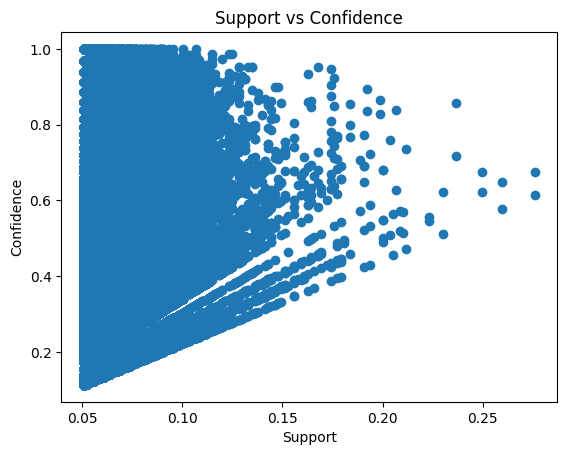

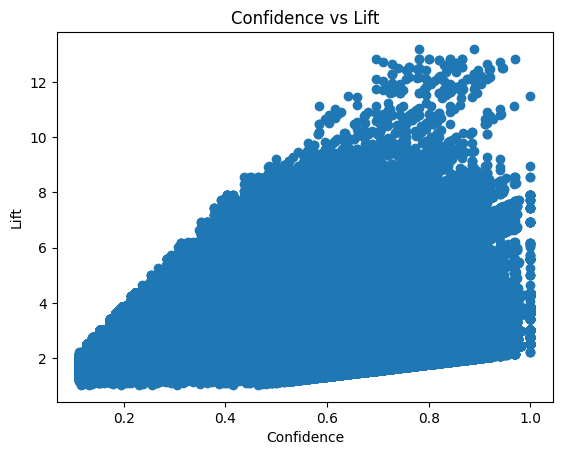

In [36]:
import matplotlib.pyplot as plt

plt.scatter(rules['support'], rules['confidence'])
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Support vs Confidence')
plt.show()

plt.scatter(rules['confidence'], rules['lift'])
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Confidence vs Lift')
plt.show()

Висновок: Отримані результати показали, що асоціативні правила можуть ефективно використовуватись у рекомендаційних системах, зокрема для формування рекомендацій типу «користувачі, яким сподобався цей фільм, також обирають інші пов’язані фільми».
Було встановлено, що параметр min_support впливає на кількість знайдених правил: при низьких значеннях знаходиться більше правил, але серед них є менш значущі, тоді як при високих значеннях залишаються лише найбільш популярні залежності. Параметр min_confidence впливає на надійність правил: більші значення забезпечують більш точні, але менш численні правила.
Таким чином, правильний вибір параметрів дозволяє знаходити баланс між кількістю та якістю асоціативних правил і підвищує ефективність рекомендаційних систем.